[0.47952794 0.47952794 0.47952794 0.47952794 0.47952794 0.47952794
 0.47952794 0.47952794 0.47952794 0.47952794 0.84965077 0.47952794
 0.47952794]


(array([0.5, 1.5, 2.5]),
 [Text(0, 0.5, '0'), Text(0, 1.5, '1'), Text(0, 2.5, '2')])

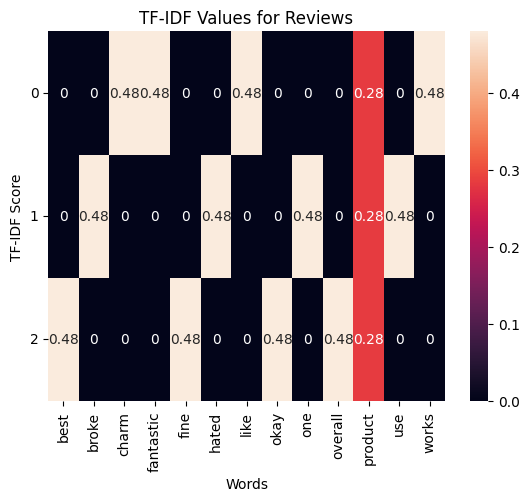

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize 
from nltk.corpus import stopwords
import string
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
reviews = [
    "The product is fantastic! It works like a charm.",
    "I hated the product. It broke after one use.",
    "Product was okay, not the best, but fine overall."
]
# Preprocess the reviews
def preprocess(text):
    text=text.lower()
    tokens=word_tokenize(text)
    stop_word=stopwords.words('english')
    clean=[word for word in tokens if word not in string.punctuation]
    clean=[word for word in clean if word not in stop_word]
    return " ".join(clean)
    
cleaned_reviews = [preprocess(review) for review in reviews]
vectorizer = TfidfVectorizer()
# Fit the vectorizer
X=vectorizer.fit_transform(cleaned_reviews)
# Print the vocabulary
words=vectorizer.get_feature_names_out()
tfidf_values=np.sum(X.toarray(),axis=0)
print(tfidf_values)
Z=pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
sns.heatmap(Z, annot=True)
plt.title('TF-IDF Values for Reviews')
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
#plt.show()